In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# path='/Users/felixbarber/Documents/GitHub/Rojas_lab_drafts/outputs'
path='/Users/barber.527/Documents/GitHub/Rojas_lab_drafts/outputs'
expt_id = '/bocillin_labeling'
data=[]
with open(path+expt_id+'/bocillin_compilation_intden.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        data.append(row) # Data should be saved in UTF-8 format
        line_count += 1
print(data)

[['8/7/24', 'PonA', 'Pbp2A/2B', 'PbpC', 'PbpD', 'DacA'], ['Background', '145.842225', '94.64695', '105.8382188', '130.9608438', '197.3939438'], ['0', '848.0046563', '494.8896938', '176.0938938', '446.558325', '1607.044625'], ['5', '942.7820875', '533.4611438', '184.2127625', '466.0785', '1756.54685'], ['10', '870.9786813', '459.8226375', '163.8779375', '405.705', '1423.322613'], ['20', '1167.089394', '518.966325', '174.1275063', '425.499275', '1406.662994'], ['30', '1191.8598', '511.2185375', '189.3938375', '416.8991938', '1296.002394'], ['40', '1570.194206', '652.4526188', '218.251925', '467.4823625', '1502.478569'], ['', '', '', '', '', ''], ['7/30/24', 'PonA', 'Pbp2A/2B', 'PbpC', 'PbpD', 'DacA'], ['Background', '42.689175', '52.59565', '35.25865', '44.910025', '69.35375'], ['0', '329.8831', '240.815375', '60.1536', '172.046575', '609.9217'], ['5', '317.04025', '232.563075', '58.54885', '164.093375', '524.594325'], ['10', '354.0366', '232.84315', '55.9455', '158.725425', '491.01575']

In [3]:
cols=['Date', 'PBP', 'Intensity' , 'Time (min)']
df=pd.DataFrame(columns=cols)
dates=['8/7/24', '7/30/24', '8/1/24']
for line in data:
    if line[0] in dates:
        temp_date=line[0]
        temp_prots=line[1:]
    elif line[0]=='Background':
        temp_norms=line[1:]
    elif line[0]!='':
        for ind in np.arange(1,len(line)):
            temp_data=[[temp_date, temp_prots[ind-1], float(line[ind])-float(temp_norms[ind-1]), float(line[0])]]
            temp_df=pd.DataFrame(columns=cols,data=temp_data)
            df=pd.concat([df,temp_df])
            
        

In [5]:
cols=['Date', 'Time (min)']+list(df.PBP.unique())
df1=pd.DataFrame(columns=cols)
dates=list(df.Date.unique())
for line in data:
    if line[0] in dates:
        temp_vals=line[:]
    elif line[0]=='Background':
        temp_norms=line[:]
    elif line[0]!='':
        temp_data=[temp_vals[0], int(line[0])]
        for prot in cols[2:]:
            temp_ind=temp_vals.index(prot)
            temp_data+=[float(line[temp_ind])-float(temp_norms[temp_ind])]
        temp_df=pd.DataFrame(columns=cols,data=[temp_data])
        df1=pd.concat([df1,temp_df])
            
df1=df1.reset_index()

In [7]:
df1['PBP1/Pbp2A']=df1['PonA']/df1['Pbp2A/2B']
df1['PBP1/PbpD']=df1['PonA']/df1['PbpD']
df1['Pbp2A/PbpD']=df1['Pbp2A/2B']/df1['PbpD']
df1['PbpC/PbpD']=df1['PbpC']/df1['PbpD']
df1['DacA/PbpD']=df1['DacA']/df1['PbpD']

In [8]:

temp=[]
for date in df1.Date.unique():
    subset=(df1.Date==date)*(df1['Time (min)']==0)
    # print(subset)
    # print(df1.loc[subset])
    temp+=list(df1[df1.Date==date]['PBP1/PbpD']/float(df1[subset]['PBP1/PbpD']))
# print(temp)
df1['PBP1/PbpD norm.']=temp
# df1.head(20)

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/276093106.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df=df1.groupby(['Time (min)']).mean()
/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/276093106.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sem is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df1=df1.groupby(['Time (min)']).sem()


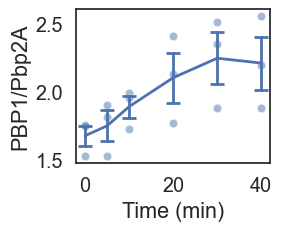

In [19]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.3)
sns.set_style('white')
temp_df=df1.groupby(['Time (min)']).mean()
temp_df1=df1.groupby(['Time (min)']).sem()
sns.lineplot(data=df1,x='Time (min)',y='PBP1/Pbp2A',estimator='mean',errorbar='se',err_style='bars',err_kws={'capsize':5.0,'capthick':2.0,'elinewidth':2.0},lw=2.0)
sns.scatterplot(data=df1,x='Time (min)',y='PBP1/Pbp2A',alpha=0.5)
ax=plt.gca()
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbp2A_timeplot.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbp2A_timeplot.pdf',bbox_inches='tight')

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/1010066259.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df=df1.groupby(['Time (min)']).mean()
/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/1010066259.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sem is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df1=df1.groupby(['Time (min)']).sem()


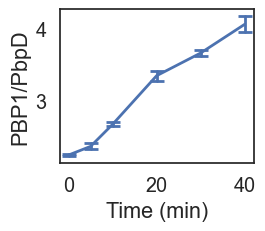

In [10]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.3)
sns.set_style('white')
temp_df=df1.groupby(['Time (min)']).mean()
temp_df1=df1.groupby(['Time (min)']).sem()
sns.lineplot(data=df1,x='Time (min)',y='PBP1/PbpD',estimator='mean',errorbar='se',err_style='bars',err_kws={'capsize':5.0,'capthick':2.0,'elinewidth':2.0},lw=2.0)
ax=plt.gca()
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbpD_timeplot.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbpD_timeplot.eps',bbox_inches='tight')

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/2402143616.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df=df1.groupby(['Time (min)']).mean()
/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/2402143616.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sem is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df1=df1.groupby(['Time (min)']).sem()


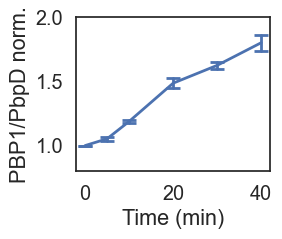

In [11]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.3)
sns.set_style('white')
temp_df=df1.groupby(['Time (min)']).mean()
temp_df1=df1.groupby(['Time (min)']).sem()
sns.lineplot(data=df1,x='Time (min)',y='PBP1/PbpD norm.',estimator='mean',errorbar='se',err_style='bars',err_kws={'capsize':5.0,'capthick':2.0,'elinewidth':2.0},lw=2.0)
ax=plt.gca()
ax.set_ylim(ymin=0.8,ymax=2.0)
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbpD_timeplot_norm.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbpD_timeplot_norm.eps',bbox_inches='tight')

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/1886892524.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='PBP1/Pbp2A',errorbar='se',capsize=0.5,errwidth=2.0)
/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/1886892524.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='PBP1/Pbp2A',errorbar='se',capsize=0.5,errwidth=2.0,hue='Date')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


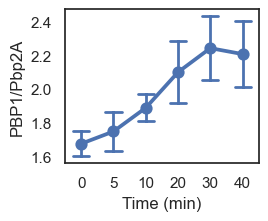

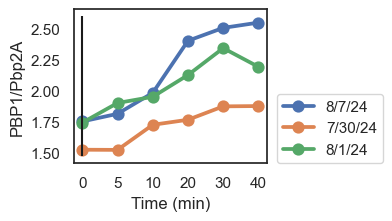

In [12]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('white')
sns.pointplot(data=df1,x='Time (min)', y='PBP1/Pbp2A',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
# plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbp2A.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbp2A.eps',bbox_inches='tight')
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('white')
sns.pointplot(data=df1,x='Time (min)', y='PBP1/Pbp2A',errorbar='se',capsize=0.5,errwidth=2.0,hue='Date')
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
plt.legend(loc=[1.05,0.0])
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbp2A_dated.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbp2A_dated.eps',bbox_inches='tight')

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/369632817.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='PonA',errorbar='se',capsize=0.5,errwidth=2.0)


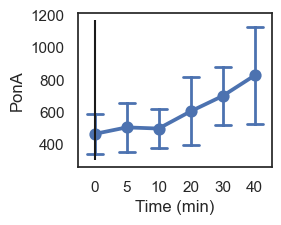

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/369632817.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='Pbp2A/2B',errorbar='se',capsize=0.5,errwidth=2.0)


<Figure size 640x480 with 0 Axes>

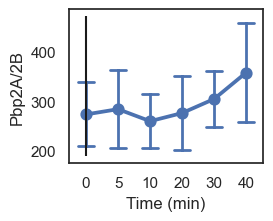

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/369632817.py:24: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='PbpC',errorbar='se',capsize=0.5,errwidth=2.0)


<Figure size 640x480 with 0 Axes>

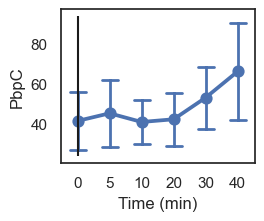

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/369632817.py:34: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='PbpD',errorbar='se',capsize=0.5,errwidth=2.0)


<Figure size 640x480 with 0 Axes>

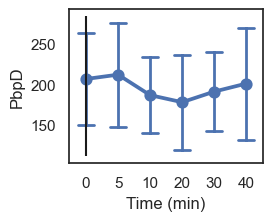

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/369632817.py:44: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='DacA',errorbar='se',capsize=0.5,errwidth=2.0)


<Figure size 640x480 with 0 Axes>

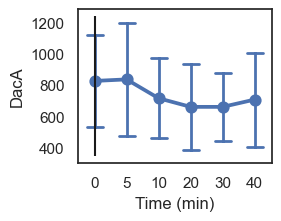

<Figure size 640x480 with 0 Axes>

In [13]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('white')
sns.pointplot(data=df1,x='Time (min)', y='PonA',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA.eps',bbox_inches='tight')
plt.show()
plt.clf()
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('white')
sns.pointplot(data=df1,x='Time (min)', y='Pbp2A/2B',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbp2A.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbp2A.eps',bbox_inches='tight')
plt.show()
plt.clf()
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('white')
sns.pointplot(data=df1,x='Time (min)', y='PbpC',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbpC.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbpC.eps',bbox_inches='tight')
plt.show()
plt.clf()
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('white')
sns.pointplot(data=df1,x='Time (min)', y='PbpD',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbpD.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbpD.eps',bbox_inches='tight')
plt.show()
plt.clf()
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('white')
sns.pointplot(data=df1,x='Time (min)', y='DacA',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_dacA.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_dacA.eps',bbox_inches='tight')
plt.show()
plt.clf()

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/3215667419.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='PBP1/PbpD',errorbar='se',capsize=0.5,errwidth=2.0)


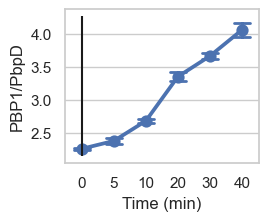

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/3215667419.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='Pbp2A/PbpD',errorbar='se',capsize=0.5,errwidth=2.0)


<Figure size 640x480 with 0 Axes>

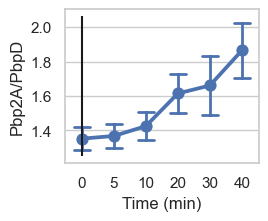

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/3215667419.py:24: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='PbpC/PbpD',errorbar='se',capsize=0.5,errwidth=2.0)


<Figure size 640x480 with 0 Axes>

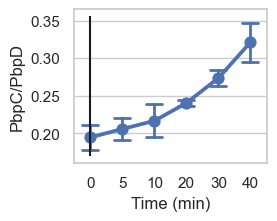

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_79045/3215667419.py:34: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.pointplot(data=df1,x='Time (min)', y='DacA/PbpD',errorbar='se',capsize=0.5,errwidth=2.0)


<Figure size 640x480 with 0 Axes>

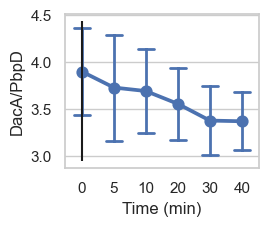

<Figure size 640x480 with 0 Axes>

In [14]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('whitegrid')
sns.pointplot(data=df1,x='Time (min)', y='PBP1/PbpD',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbpD.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_ponA_pbpD.eps',bbox_inches='tight')
plt.show()
plt.clf()
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('whitegrid')
sns.pointplot(data=df1,x='Time (min)', y='Pbp2A/PbpD',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbp2A_pbpD.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbp2A_pbpD.eps',bbox_inches='tight')
plt.show()
plt.clf()
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('whitegrid')
sns.pointplot(data=df1,x='Time (min)', y='PbpC/PbpD',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbpC_pbpD.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_pbpC_pbpD.eps',bbox_inches='tight')
plt.show()
plt.clf()
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.0)
sns.set_style('whitegrid')
sns.pointplot(data=df1,x='Time (min)', y='DacA/PbpD',errorbar='se',capsize=0.5,errwidth=2.0)
ax=plt.gca()
plt.vlines(0.0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='-', colors='k')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_dacA_pbpD.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_dacA_pbpD.eps',bbox_inches='tight')
plt.show()
plt.clf()

In [15]:
temp_df=df1.groupby(['Time (min)'])['PBP1/PbpD norm.'].mean()
temp_df1=df1.groupby(['Time (min)'])['PBP1/PbpD norm.'].sem()

Now we will incorporate western data to plot relative PBP1 staining for both methods alongside one another

In [16]:
user='barber.527'
in_path='/Users/'+user+'/Documents/Rojas_Lab/data'
out_path='/Users/'+user+'/Documents/GitHub/Rojas_lab_drafts/outputs'
expt_id = '/250911_ponA_westerns'
data=[]
with open(in_path+expt_id+expt_id+'_data_cumulative.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        data.append(row) # Data should be saved in UTF-8 format
        line_count += 1
print(data)
cols=['Date', 'Stain', 'Intensity' , 'Time (min)']
df=pd.DataFrame(columns=cols)
dates=['5/7/25', '5/9/25']
for line in data:
    if line[0] in dates:
        temp_date=line[0]
        temp_prots=line[1:]
    elif line[0]!='':
        for ind in np.arange(1,len(line)):
            temp_data=[[temp_date, temp_prots[ind-1], float(line[ind]), float(line[0])]]
            temp_df=pd.DataFrame(columns=cols,data=temp_data)
            df=pd.concat([df,temp_df])       
cols=['Date', 'Time (min)']+list(df.Stain.unique())
df2=pd.DataFrame(columns=cols)
dates=list(df.Date.unique())
for line in data:
    if line[0] in dates:
        temp_vals=line[:]
    elif line[0]!='':
        temp_data=[temp_vals[0], int(line[0])]
        for prot in cols[2:]:
            temp_ind=temp_vals.index(prot)
            temp_data+=[float(line[temp_ind])]
        temp_df=pd.DataFrame(columns=cols,data=[temp_data])
        df2=pd.concat([df2,temp_df])
df2.index=np.arange(len(df2))
df2['PBP1/SigA']=np.nan
temp_vals=np.nan*np.ones(len(df2))
for ind in range(len(df2)):
    date=df2['Date'][ind]
#     print(date)
    temp_df=df2[df2.Date==date]
    var1_norm=temp_df[temp_df['Time (min)']==0]['PBP1']
    var2_norm=temp_df[temp_df['Time (min)']==0]['SigA']
    temp_vals[ind]=df2['PBP1'][ind]/df2['SigA'][ind]/var1_norm*var2_norm
df2['PBP1/SigA norm']=temp_vals
df2['PBP1/SigA']=df2['PBP1']/df2['SigA']

[['5/9/25', 'PBP1', 'SigA'], ['0', '1596.010888', '3023.510338'], ['10', '1471.758988', '2847.786588'], ['20', '1912.222538', '3391.792738'], ['30', '2130.916238', '3297.026113'], ['40', '2386.490313', '3264.509813'], ['60', '2684.647113', '3305.440988'], ['', '', ''], ['5/7/25', 'PBP1', 'SigA'], ['0', '994.983725', '3740.26795'], ['10', '986.456625', '4418.934425'], ['20', '1143.3745', '4317.320425'], ['30', '1542.73015', '4320.54005'], ['40', '2118.028825', '4331.320975'], ['60', '1723.25675', '3791.7516']]


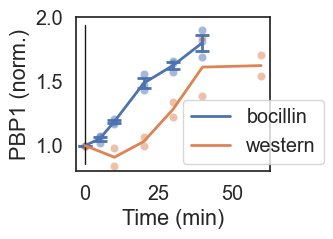

In [18]:
fig=plt.figure(figsize=[2.5,2])
sns.set(font_scale=1.3)
sns.set_style('white')
sns.lineplot(data=df1,x='Time (min)',y='PBP1/PbpD norm.',estimator='mean',errorbar='se',err_style='bars',err_kws={'capsize':5.0,'capthick':2.0,'elinewidth':2.0},lw=2.0,label='bocillin')
sns.scatterplot(data=df1,x='Time (min)',y='PBP1/PbpD norm.',alpha=0.5)

ax=plt.gca()
ax.axvline(ymin=0.05,ymax=0.95,x=0.0,color='k',linewidth=1.0)
sns.lineplot(data=df2,x='Time (min)',y='PBP1/SigA norm',estimator='mean',errorbar=None,err_style='bars',err_kws={'capsize':5.0,'capthick':2.0,'elinewidth':2.0},lw=2.0,label='western')
sns.scatterplot(data=df2,x='Time (min)',y='PBP1/SigA norm',alpha=0.5)
ax.set_ylim(ymin=0.8,ymax=2.0)
plt.legend(loc=[0.55,0.05])
ax.set_ylabel('PBP1 (norm.)')
plt.show()
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_PBP1_PbpD_norm_timeplot_norm_western.png',dpi=300,bbox_inches='tight')
fig.savefig('./outputs/bocillin_labeling/intensity_cumulative_PBP1_PbpD_norm_timeplot_norm_western.pdf',bbox_inches='tight')